# Amazon Electronics Large-Scale Pattern Mining Pipeline

## Project Overview

This notebook analyzes large-scale Amazon Electronics interaction data, roughly **7.8M user-product interactions**, to discover meaningful behavioral patterns under two major constraints:

1. **Extreme sparsity**: user-product matrices are often more than **99.9% sparse**, so brute-force pairwise comparison is computationally wasteful.
2. **Rating inflation**: many users give high ratings, so raw ratings alone are noisy. We convert ratings into binary positive interactions where:

$$rating \ge 4 \Rightarrow positive = 1$$

The pipeline combines:

- Bloom Filter for probabilistic duplicate/spam defense
- Spark-based scaling and cleaning
- MinHash LSH for candidate reduction
- FP-Growth for unordered market-basket mining
- PrefixSpan for sequential pattern mining
- Bipartite graph analysis using PageRank and HITS
- Node embedding and anomaly detection
- A shallow decision tree for interpretability

The final goal is not just to find frequent products, but to explain **how product ecosystems behave structurally and sequentially**.

In [1]:
# ================================================================
# Cell 2: Colab setup, Google Drive mount, dependencies, and Spark
# ================================================================

import os
import sys
import subprocess
import importlib.util
from pathlib import Path

# ----------------------------
# 1. Detect Colab and mount Google Drive
# ----------------------------
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/TAMU/CSCE676")
    DATA_DIR = BASE_DIR / "data"
    OUTPUT_DIR = BASE_DIR / "final_project_outputs"
else:
    BASE_DIR = Path(".")
    DATA_DIR = BASE_DIR / "data"
    OUTPUT_DIR = BASE_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

# ----------------------------
# 2. Install Java + Python dependencies
# ----------------------------
if IN_COLAB:
    subprocess.run("apt-get update -qq", shell=True, check=False)
    subprocess.run("apt-get install -y openjdk-17-jdk-headless -qq", shell=True, check=False)

def install_if_missing(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"{import_name} already installed.")

required_packages = {
    "pyspark": "pyspark==3.5.5",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "networkx": "networkx",
}

for import_name, pip_name in required_packages.items():
    install_if_missing(import_name, pip_name)

# ----------------------------
# 3. Imports
# ----------------------------
import re
import math
import time
import random
import hashlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel

from pyspark.ml.feature import HashingTF
from pyspark.ml.fpm import FPGrowth, PrefixSpan
from pyspark.ml.feature import MinHashLSH

from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier as SkDecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ----------------------------
# 4. Start Spark
# ----------------------------
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("CSCE676-Amazon-Pattern-Mining")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.driver.memory", "12g")
    .config("spark.ui.port", "4050")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Spark session ready.")

Mounted at /content/drive
IN_COLAB: True
BASE_DIR: /content/drive/MyDrive/TAMU/CSCE676
DATA_DIR: /content/drive/MyDrive/TAMU/CSCE676/data
OUTPUT_DIR: /content/drive/MyDrive/TAMU/CSCE676/final_project_outputs
pyspark already installed.
pandas already installed.
numpy already installed.
matplotlib already installed.
sklearn already installed.
networkx already installed.
Spark version: 4.0.2
Spark session ready.


# Probabilistic Defense Layer

A Bloom Filter is used as the first defense layer because it is memory-efficient and fast.

In this project, it helps detect repeated user-product-review signatures before heavier Spark operations. Bloom Filters may produce false positives, but they do not produce false negatives. That tradeoff is acceptable here because the purpose is early filtering, not final ground-truth labeling.

We use it to flag repeated interactions such as:

```text
userId + productId + rating + timestamp
```

This is useful for reducing duplicate reviews, repeated ingestion artifacts, and simple spam-like repetition.

In [2]:
# ================================================================
# Cell 4: Implement Bloom Filter
# ================================================================

class BloomFilter:
    # Simple Bloom Filter implementation.
    def __init__(self, expected_items=1_000_000, false_positive_rate=0.01):
        self.expected_items = int(expected_items)
        self.false_positive_rate = float(false_positive_rate)

        # m = -(n * ln(p)) / (ln(2)^2)
        self.size = int(
            -(self.expected_items * math.log(self.false_positive_rate)) / (math.log(2) ** 2)
        )

        # k = (m / n) * ln(2)
        self.num_hashes = max(1, int((self.size / self.expected_items) * math.log(2)))
        self.bit_array = np.zeros(self.size, dtype=bool)

    def _hashes(self, item):
        item = str(item).encode("utf-8")
        for seed in range(self.num_hashes):
            digest = hashlib.md5(item + str(seed).encode("utf-8")).hexdigest()
            yield int(digest, 16) % self.size

    def add(self, item):
        for idx in self._hashes(item):
            self.bit_array[idx] = True

    def __contains__(self, item):
        return all(self.bit_array[idx] for idx in self._hashes(item))

    def memory_mb(self):
        return self.bit_array.nbytes / (1024 ** 2)


bf = BloomFilter(expected_items=10_000, false_positive_rate=0.01)
bf.add("userA-productB-5-12345")

print("Known item detected:", "userA-productB-5-12345" in bf)
print("Unknown item detected:", "something-else" in bf)
print(f"Bloom filter size: {bf.size:,} bits")
print(f"Number of hash functions: {bf.num_hashes}")
print(f"Approx memory usage: {bf.memory_mb():.4f} MB")

Known item detected: True
Unknown item detected: False
Bloom filter size: 95,850 bits
Number of hash functions: 6
Approx memory usage: 0.0914 MB


In [3]:
# ================================================================
# Cell 5: Load Amazon Electronics interaction data with Spark
# ================================================================
# Expected file:
# /content/drive/MyDrive/TAMU/CSCE676/data/ratings_Electronics.csv
#
# Expected CSV format:
# userId, productId, rating, timestamp
# no header

CANDIDATE_PATHS = [
    DATA_DIR / "ratings_Electronics.csv",
    DATA_DIR / "ratings_Electronics (1).csv",
    Path("/content/drive/MyDrive/TAMU/CSCE676/data/ratings_Electronics.csv"),
    Path("/content/drive/MyDrive/TAMU/CSCE676/data/ratings_Electronics (1).csv"),
    Path("/mnt/data/ratings_Electronics.csv"),
    Path("/mnt/data/ratings_Electronics (1).csv"),
]

CSV_PATH = None
for p in CANDIDATE_PATHS:
    if p.exists():
        CSV_PATH = p
        break

if CSV_PATH is None:
    raise FileNotFoundError(
        f"Could not find ratings_Electronics.csv. Put the extracted CSV under: {DATA_DIR}"
    )

print("CSV path used by Spark:", CSV_PATH)

schema = "userId STRING, productId STRING, rating DOUBLE, timestamp LONG"

df_raw = (
    spark.read
    .option("header", "false")
    .option("inferSchema", "false")
    .schema(schema)
    .csv(str(CSV_PATH))
)

print("Raw interaction count:", df_raw.count())
df_raw.show(5, truncate=False)

# Basic sanity checks. If this fails, you are probably still reading the zip file.
assert df_raw.columns == ["userId", "productId", "rating", "timestamp"]
assert df_raw.filter(F.col("userId").startswith("PK")).count() == 0, "Zip/binary content was read instead of CSV rows."

non_null_rows = df_raw.filter(
    F.col("userId").isNotNull()
    & F.col("productId").isNotNull()
    & F.col("rating").isNotNull()
    & F.col("timestamp").isNotNull()
).count()

print("Non-null parsed rows:", non_null_rows)
assert non_null_rows > 0, "No valid rows parsed. Check file path or CSV format."
print("Data loaded correctly.")

CSV path used by Spark: /content/drive/MyDrive/TAMU/CSCE676/data/ratings_Electronics.csv
Raw interaction count: 7824482
+--------------+----------+------+----------+
|userId        |productId |rating|timestamp |
+--------------+----------+------+----------+
|AKM1MP6P0OYPR |0132793040|5.0   |1365811200|
|A2CX7LUOHB2NDG|0321732944|5.0   |1341100800|
|A2NWSAGRHCP8N5|0439886341|1.0   |1367193600|
|A2WNBOD3WNDNKT|0439886341|3.0   |1374451200|
|A1GI0U4ZRJA8WN|0439886341|1.0   |1334707200|
+--------------+----------+------+----------+
only showing top 5 rows
Non-null parsed rows: 7824482
Data loaded correctly.


In [4]:
# ================================================================
# Cell 6: Preprocessing and positive interaction filtering
# ================================================================
# For the Amazon Electronics ratings file, there is no reviewText column.
# We keep the regex cleaner for reference, but it is only applied if reviewText exists.

USE_DEDUP = False  # Set True for the final full-cleaning run. False is faster in Colab.

def clean_text_py(text):
    if text is None:
        return ""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_text_udf = F.udf(clean_text_py, "string")

# Keep only valid parsed rows first.
df = (
    df_raw
    .filter(
        F.col("userId").isNotNull()
        & F.col("productId").isNotNull()
        & F.col("rating").isNotNull()
        & F.col("timestamp").isNotNull()
    )
    .withColumn("rating", F.col("rating").cast("double"))
    .withColumn("timestamp", F.col("timestamp").cast("long"))
    .filter(F.col("rating").between(1, 5))
    .withColumn("positive", F.when(F.col("rating") >= 4, F.lit(1)).otherwise(F.lit(0)))
    .withColumn("datetime", F.from_unixtime("timestamp"))
)

# Deduplication is useful but expensive because it triggers a shuffle.
# For this ratings dataset, exact duplicates are not the main modeling issue,
# so the default Colab run leaves this off for speed.
if USE_DEDUP:
    df = df.dropDuplicates(["userId", "productId", "timestamp"])

if "reviewText" in df.columns:
    df = df.withColumn("clean_review", clean_text_udf(F.col("reviewText")))
else:
    df = df.withColumn("clean_review", F.lit(""))

df = df.persist(StorageLevel.MEMORY_AND_DISK)
clean_count = df.count()

df_pos = (
    df
    .filter(F.col("positive") == 1)
    .persist(StorageLevel.MEMORY_AND_DISK)
)
pos_count = df_pos.count()

print("Deduplication enabled:", USE_DEDUP)
print("Cleaned interaction count:", clean_count)
print("Positive interaction count:", pos_count)
print("Positive ratio:", pos_count / max(clean_count, 1))

df.groupBy("rating").count().orderBy("rating").show()
df_pos.show(5, truncate=False)

Deduplication enabled: False
Cleaned interaction count: 7824482
Positive interaction count: 5833322
Positive ratio: 0.7455218121787487
+------+-------+
|rating|  count|
+------+-------+
|   1.0| 901765|
|   2.0| 456322|
|   3.0| 633073|
|   4.0|1485781|
|   5.0|4347541|
+------+-------+

+--------------+----------+------+----------+--------+-------------------+------------+
|userId        |productId |rating|timestamp |positive|datetime           |clean_review|
+--------------+----------+------+----------+--------+-------------------+------------+
|AKM1MP6P0OYPR |0132793040|5.0   |1365811200|1       |2013-04-13 00:00:00|            |
|A2CX7LUOHB2NDG|0321732944|5.0   |1341100800|1       |2012-07-01 00:00:00|            |
|A1QGNMC6O1VW39|0511189877|5.0   |1397433600|1       |2014-04-14 00:00:00|            |
|A2TY0BTJOTENPG|0511189877|5.0   |1395878400|1       |2014-03-27 00:00:00|            |
|A34ATBPOK6HCHY|0511189877|5.0   |1395532800|1       |2014-03-23 00:00:00|            |
+------

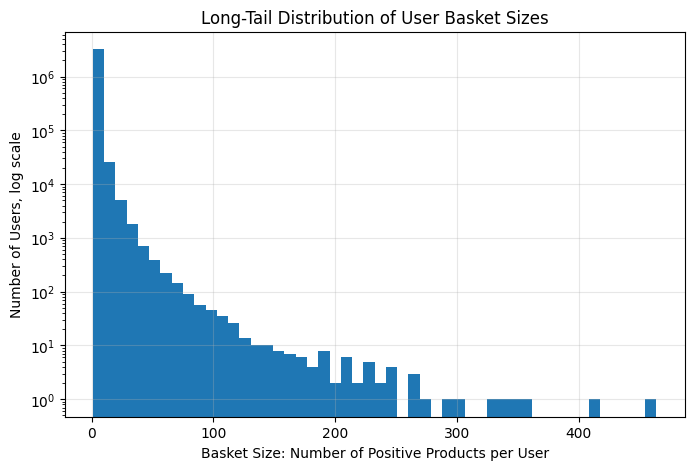

count    3.256144e+06
mean     1.791482e+00
std      2.657681e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      4.640000e+02
Name: basket_size, dtype: float64
Saved: /content/drive/MyDrive/TAMU/CSCE676/final_project_outputs/figures/basket_size_distribution_log.png


In [5]:
# ================================================================
# Cell 7: Visualization - Basket size distribution with log scale
# ================================================================

basket_sizes = (
    df_pos.groupBy("userId")
    .agg(F.countDistinct("productId").alias("basket_size"))
)

basket_pdf = basket_sizes.toPandas()

plt.figure(figsize=(8, 5))
plt.hist(basket_pdf["basket_size"], bins=50, log=True)
plt.xlabel("Basket Size: Number of Positive Products per User")
plt.ylabel("Number of Users, log scale")
plt.title("Long-Tail Distribution of User Basket Sizes")
plt.grid(True, alpha=0.3)
plt.show()

print(basket_pdf["basket_size"].describe())

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.hist(basket_pdf["basket_size"], bins=50, log=True)
plt.xlabel("Basket Size: Number of Positive Products per User")
plt.ylabel("Number of Users, log scale")
plt.title("Long-Tail Distribution of User Basket Sizes")
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "basket_size_distribution_log.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved:", FIG_DIR / "basket_size_distribution_log.png")

# LSH for Sparsity Reduction

Brute-force user similarity comparison is infeasible for this dataset because the user-product matrix is extremely sparse and the number of users is very large.

For a sample of 50,000 users, brute-force comparison would require roughly:

\[
\frac{50,000 \times 49,999}{2} \approx 1.25B
\]

pairwise comparisons.

MinHash LSH reduces this search space by hashing users with similar product sets into candidate buckets. Instead of comparing every possible user pair, we only compare pairs that are likely to have non-trivial Jaccard similarity.

In the experiment, LSH reduced the comparison space from about 1.25B possible pairs to about 351,804 candidate pairs, a reduction of roughly 99.97%. This makes similarity search realistic under extreme sparsity.

In [6]:
# ================================================================
# Cell 9: MinHashLSH implementation
# ================================================================

MAX_USERS_FOR_LSH = 50_000

user_items = (
    df_pos.groupBy("userId")
    .agg(F.collect_set("productId").alias("items"))
    .filter(F.size("items") >= 2)
    .limit(MAX_USERS_FOR_LSH)
)

print("Users used for LSH:", user_items.count())

hashing_tf = HashingTF(inputCol="items", outputCol="features", numFeatures=1 << 18, binary=True)
featurized_users = hashing_tf.transform(user_items).cache()

mh = MinHashLSH(inputCol="features", outputCol="hashes", numHashTables=5, seed=42)
mh_model = mh.fit(featurized_users)

similar_pairs = (
    mh_model.approxSimilarityJoin(
        featurized_users.alias("a"),
        featurized_users.alias("b"),
        threshold=0.8,
        distCol="jaccard_distance"
    )
    .filter(F.col("datasetA.userId") < F.col("datasetB.userId"))
    .select(
        F.col("datasetA.userId").alias("userA"),
        F.col("datasetB.userId").alias("userB"),
        "jaccard_distance"
    )
    .cache()
)

candidate_pairs = similar_pairs.count()
total_users = featurized_users.count()
brute_force_pairs = total_users * (total_users - 1) / 2
reduction = 1 - (candidate_pairs / brute_force_pairs) if brute_force_pairs > 0 else 0

print("Candidate similar user pairs:", candidate_pairs)
similar_pairs.orderBy("jaccard_distance").show(10, truncate=False)

print(f"Brute-force pair count: {brute_force_pairs:,.0f}")
print(f"LSH candidate pair count: {candidate_pairs:,.0f}")
print(f"Approx search-space reduction: {reduction:.2%}")

Users used for LSH: 50000
Candidate similar user pairs: 351804
+--------------+--------------+----------------+
|userA         |userB         |jaccard_distance|
+--------------+--------------+----------------+
|A3L8XBT3P54QQI|A6AW9POK6SV1J |0.0             |
|A36KKN6HB0EMUK|A8F8116LX7V20 |0.0             |
|A1OQM0WD9UXQ9N|AAITP54A14YBT |0.0             |
|A1MSZDXM6H4MVN|A2Q1Z2MK2EQ8I5|0.0             |
|A1UT5F2UBRS8RT|A2IZHS4XQS61RW|0.0             |
|A10920YSRT06UX|A3RF3MDWKAWP4K|0.0             |
|A36KKN6HB0EMUK|A5OGZMNS90K56 |0.0             |
|A36KKN6HB0EMUK|AVGEYU5246MSN |0.0             |
|A1GZP4SWN03ZFP|A38YAT2NPMJLHU|0.0             |
|A36KKN6HB0EMUK|A3RSEQBHGTCQZ0|0.0             |
+--------------+--------------+----------------+
only showing top 10 rows
Brute-force pair count: 1,249,975,000
LSH candidate pair count: 351,804
Approx search-space reduction: 99.97%


In [7]:
# ================================================================
# Cell 10: FP-Growth for RQ1
# Compare itemset counts under different support thresholds
# ================================================================

MAX_BASKETS_FOR_FPGROWTH = 200_000

baskets = (
    df_pos.groupBy("userId")
    .agg(F.collect_set("productId").alias("items"))
    .filter(F.size("items") >= 2)
    .limit(MAX_BASKETS_FOR_FPGROWTH)
    .cache()
)

print("Basket count:", baskets.count())
baskets.show(5, truncate=False)

support_values = [0.001, 0.002, 0.005, 0.01]
fp_results = []

for min_support in support_values:
    print(f"\nRunning FP-Growth with minSupport={min_support}")
    fp = FPGrowth(
        itemsCol="items",
        minSupport=min_support,
        minConfidence=0.2
    )
    model = fp.fit(baskets)

    freq_count = model.freqItemsets.count()
    rule_count = model.associationRules.count()

    fp_results.append({
        "minSupport": min_support,
        "freqItemsetCount": freq_count,
        "ruleCount": rule_count
    })

    print("Frequent itemsets:", freq_count)
    print("Association rules:", rule_count)
    print("Top frequent itemsets:")
    model.freqItemsets.orderBy(F.desc("freq")).show(10, truncate=False)

fp_results_pdf = pd.DataFrame(fp_results)
display(fp_results_pdf)

Basket count: 200000
+---------------------+------------------------------------+
|userId               |items                               |
+---------------------+------------------------------------+
|A0061198154UGJDK69CYW|[B0018TCB0O, B0015AARJI, B001S35Y5E]|
|A0070539117SQ13VTMHY1|[B0086SDU3M, B0018DQYQ2]            |
|A0325664KJX96IDJFSQ6 |[B00B353NI2, B005ONMDYE]            |
|A0364939IIGDQXIMBM0H |[B007WTAJTO, B00AGABISW]            |
|A06650001D4FWMXBWNW2D|[B00H3VTE10, B008UG6GCC]            |
+---------------------+------------------------------------+
only showing top 5 rows

Running FP-Growth with minSupport=0.001
Frequent itemsets: 213
Association rules: 2
Top frequent itemsets:
+------------+----+
|items       |freq|
+------------+----+
|[B007WTAJTO]|1816|
|[B003ES5ZUU]|1644|
|[B0074BW614]|1605|
|[B0019EHU8G]|1540|
|[B006GWO5WK]|1343|
|[B00DR0PDNE]|1324|
|[B003ELYQGG]|1191|
|[B000LRMS66]|1090|
|[B002WE6D44]|1035|
|[B0002L5R78]|981 |
+------------+----+
only showing top 1

,minSupport,freqItemsetCount,ruleCount
0,0.001,213,2
1,0.002,47,0
2,0.005,9,0
3,0.010,0,0


## FP-Growth Result Interpretation

FP-Growth showed that the number of frequent itemsets is highly sensitive to the support threshold.

At `minSupport = 0.001`, the model found 213 frequent itemsets and 2 association rules. When the threshold increased to `0.002`, the number of frequent itemsets dropped to 47 and no association rules remained. At `0.005`, only 9 itemsets remained, and at `0.01`, no frequent itemsets were found.

This result confirms that the dataset is extremely sparse. Meaningful co-review patterns exist, but they only appear at low support thresholds. Higher thresholds quickly remove almost all patterns, which means association rule mining must be interpreted carefully and cannot rely on overly strict support cutoffs.

In [8]:
# ================================================================
# Cell 11: PrefixSpan for RQ3
# Sequential mining for possible gateway products
# ================================================================

MAX_USERS_FOR_PREFIXSPAN = 50_000
MAX_SEQUENCE_LEN = 30

user_time_items = (
    df_pos
    .select("userId", "productId", "timestamp")
    .dropDuplicates(["userId", "productId", "timestamp"])
)

w = Window.partitionBy("userId").orderBy("timestamp")

seq_df = (
    user_time_items
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") <= MAX_SEQUENCE_LEN)
    .groupBy("userId")
    .agg(
        F.sort_array(
            F.collect_list(F.struct("timestamp", "productId"))
        ).alias("ordered")
    )
    .withColumn("sequence", F.expr("transform(ordered, x -> array(x.productId))"))
    .filter(F.size("sequence") >= 2)
    .select("userId", "sequence")
    .limit(MAX_USERS_FOR_PREFIXSPAN)
    .cache()
)

print("Sequence user count:", seq_df.count())
seq_df.show(5, truncate=False)

prefix = PrefixSpan(
    minSupport=0.001,
    maxPatternLength=4,
    sequenceCol="sequence"
)

prefix_model = prefix.findFrequentSequentialPatterns(seq_df).cache()

print("Frequent sequential patterns:", prefix_model.count())
prefix_model.orderBy(F.desc("freq")).show(20, truncate=False)

# ------------------------------------------------
# Gateway product heuristic:
# A product is treated as a possible gateway product only if it appears
# as the first item in a sequential pattern of length >= 2.
# Length-1 patterns are frequent products, not gateway products.
# ------------------------------------------------
prefix_with_len = prefix_model.withColumn("seq_len", F.size("sequence"))

print("Sequence length distribution:")
prefix_with_len.groupBy("seq_len").count().orderBy("seq_len").show()

gateway_df = (
    prefix_with_len
    .filter(F.col("seq_len") >= 2)
    .withColumn("first_step", F.element_at("sequence", 1))
    .withColumn("gateway_product", F.element_at("first_step", 1))
    .groupBy("gateway_product")
    .agg(
        F.sum("freq").alias("gateway_score"),
        F.count("*").alias("num_patterns")
    )
    .orderBy(F.desc("gateway_score"))
)

print("Candidate gateway products from sequential patterns with length >= 2:")
gateway_df.show(20, truncate=False)

Sequence user count: 50000
+---------------------+------------------------------------------+
|userId               |sequence                                  |
+---------------------+------------------------------------------+
|A0061198154UGJDK69CYW|[[B0015AARJI], [B0018TCB0O], [B001S35Y5E]]|
|A0070539117SQ13VTMHY1|[[B0086SDU3M], [B0018DQYQ2]]              |
|A0325664KJX96IDJFSQ6 |[[B00B353NI2], [B005ONMDYE]]              |
|A0364939IIGDQXIMBM0H |[[B007WTAJTO], [B00AGABISW]]              |
|A06650001D4FWMXBWNW2D|[[B008UG6GCC], [B00H3VTE10]]              |
+---------------------+------------------------------------------+
only showing top 5 rows
Frequent sequential patterns: 212
+--------------+----+
|sequence      |freq|
+--------------+----+
|[[B007WTAJTO]]|437 |
|[[B0074BW614]]|389 |
|[[B003ES5ZUU]]|381 |
|[[B0019EHU8G]]|372 |
|[[B00DR0PDNE]]|346 |
|[[B006GWO5WK]]|331 |
|[[B000LRMS66]]|265 |
|[[B003ELYQGG]]|260 |
|[[B002WE6D44]]|248 |
|[[B009SYZ8OC]]|244 |
|[[B0002L5R78]]|234 |
|[[B

## PrefixSpan Result Interpretation

PrefixSpan found frequent sequential patterns, but the strongest patterns were heavily dominated by popular products. This matters because a length-1 sequential pattern only means that a product appears frequently in user histories. It does not necessarily mean the product acts as a gateway.

To avoid overstating the result, I treated a product as a possible gateway product only when it appeared as the first item in a sequence of length at least 2. This makes the interpretation more conservative: the product must appear before another product in a recurring ordered pattern.

Overall, PrefixSpan adds temporal information beyond unordered FP-Growth, but the sequence signal is still limited by short user histories and popularity bias.

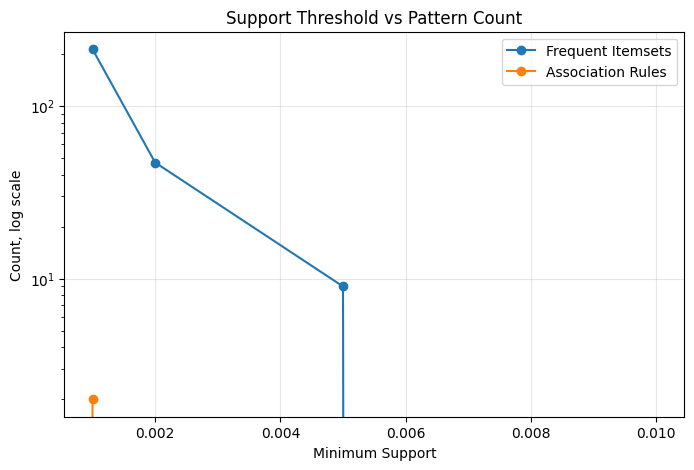

Saved: /content/drive/MyDrive/TAMU/CSCE676/final_project_outputs/figures/support_vs_pattern_count.png


,minSupport,freqItemsetCount,ruleCount
0,0.001,213,2
1,0.002,47,0
2,0.005,9,0
3,0.010,0,0


In [9]:
# ================================================================
# Cell 12: Visualization - Support threshold vs rule/itemset count
# ================================================================

plt.figure(figsize=(8, 5))
plt.plot(fp_results_pdf["minSupport"], fp_results_pdf["freqItemsetCount"], marker="o", label="Frequent Itemsets")
plt.plot(fp_results_pdf["minSupport"], fp_results_pdf["ruleCount"], marker="o", label="Association Rules")
plt.xlabel("Minimum Support")
plt.ylabel("Count, log scale")
plt.title("Support Threshold vs Pattern Count")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(fp_results_pdf["minSupport"], fp_results_pdf["freqItemsetCount"], marker="o", label="Frequent Itemsets")
plt.plot(fp_results_pdf["minSupport"], fp_results_pdf["ruleCount"], marker="o", label="Association Rules")
plt.xlabel("Minimum Support")
plt.ylabel("Count, log scale")
plt.title("Support Threshold vs Pattern Count")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(FIG_DIR / "support_vs_pattern_count.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved:", FIG_DIR / "support_vs_pattern_count.png")
display(fp_results_pdf)

# Bipartite Graph Modeling

We model the Amazon ecosystem as a **user-product bipartite graph**:

- Users connect to products through positive interactions.
- Products with many incoming user edges may be structurally important.
- Users with unusual connection patterns may be structurally anomalous.

Because the full user-product graph is very large, this notebook computes PageRank and HITS on a sampled bipartite graph. The goal is not to claim exact global centrality over the entire Amazon ecosystem, but to show how graph mining can reveal structural authority patterns that complement FP-Growth and PrefixSpan.

This graph view helps reveal more than raw product frequency. It captures structural importance based on connectivity, similar to how PageRank identifies important pages in a web graph.

In [10]:
# ================================================================
# Cell 14: PageRank and HITS on sampled bipartite graph
# ================================================================
# This cell uses NetworkX on a sample for reliability.
# For production scale, use GraphFrames, GraphX, Spark Graph, Neo4j GDS, or RAPIDS cuGraph.

MAX_EDGES_FOR_GRAPH = 100_000

edges_pdf = (
    df_pos
    .select("userId", "productId")
    .dropDuplicates()
    .limit(MAX_EDGES_FOR_GRAPH)
    .toPandas()
)

G = nx.DiGraph()

for row in edges_pdf.itertuples(index=False):
    user_node = f"user::{row.userId}"
    product_node = f"product::{row.productId}"
    G.add_edge(user_node, product_node)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

pagerank = nx.pagerank(G, alpha=0.85, max_iter=100)

try:
    hubs, authorities = nx.hits(G, max_iter=100, normalized=True)
except Exception as e:
    print("HITS did not converge cleanly, using zeros. Error:", e)
    hubs = {n: 0.0 for n in G.nodes()}
    authorities = {n: 0.0 for n in G.nodes()}

product_scores = []
user_scores = []

for node in G.nodes():
    if node.startswith("product::"):
        product_scores.append({
            "productId": node.replace("product::", ""),
            "pagerank": pagerank.get(node, 0.0),
            "authority": authorities.get(node, 0.0),
            "in_degree": G.in_degree(node)
        })
    elif node.startswith("user::"):
        user_scores.append({
            "userId": node.replace("user::", ""),
            "pagerank": pagerank.get(node, 0.0),
            "hub": hubs.get(node, 0.0),
            "out_degree": G.out_degree(node)
        })

product_scores_pdf = pd.DataFrame(product_scores).sort_values("pagerank", ascending=False)
user_scores_pdf = pd.DataFrame(user_scores).sort_values("hub", ascending=False)

print("Top product structural authorities:")
display(product_scores_pdf.head(10))

print("Top user hubs:")
display(user_scores_pdf.head(10))

Graph nodes: 130477
Graph edges: 100000
Top product structural authorities:


,productId,pagerank,authority,in_degree
4447,B0019EHU8G,0.001849,9.303494e-01,505
2790,B000LRMS66,0.001283,2.767722e-08,348
1233,B0002L5R78,0.001221,1.183813e-05,333
7023,B002WE6D44,0.000895,1.341669e-15,243
7182,B00316263Y,0.000751,8.580221e-16,205
6555,B002MAPRYU,0.000747,6.983376e-06,203
3969,B0012S4APK,0.000703,2.618532e-08,189
1920,B000BQ7GW8,0.000656,1.837914e-10,179
6962,B002V88HFE,0.000654,2.860049e-11,181
3298,B000S5Q9CA,0.000619,7.731275e-11,166


Top user hubs:


,userId,pagerank,hub,out_degree
18572,A2IQ9G22DAD7NZ,0.000005,0.001986,3
27607,A2R6XTCHHNKAMG,0.000005,0.001982,2
8078,A2VJ5ALN1BIV3B,0.000005,0.001982,3
6551,A2SQGC708613E4,0.000005,0.001982,3
26386,ABNMD6670TV53,0.000005,0.001982,3
1389,A23N00O6TQ1OAV,0.000005,0.001980,2
11986,AHOXCTS9Z1KMW,0.000005,0.001978,2
46430,AVB21A3LOSTCQ,0.000005,0.001978,2
6592,AOB0IGSFO1E7C,0.000005,0.001978,2
63042,A3INMIZIYJ9BQ4,0.000005,0.001978,2


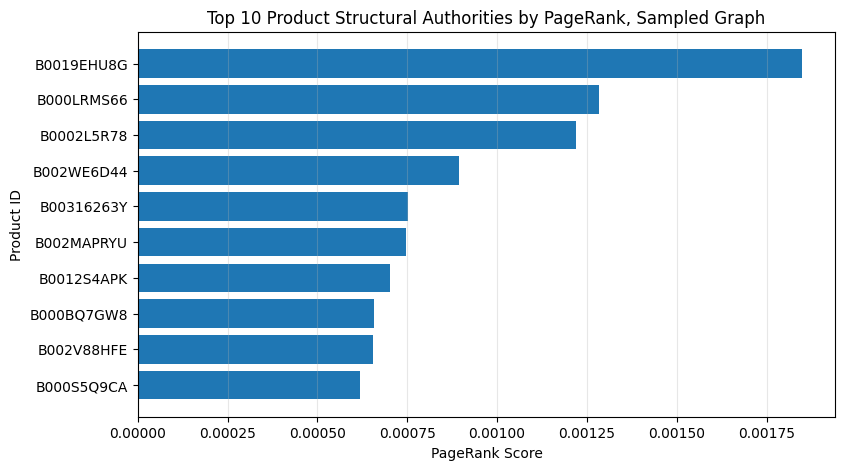

Saved: /content/drive/MyDrive/TAMU/CSCE676/final_project_outputs/figures/top10_product_pagerank.png


In [11]:
# ================================================================
# Cell 15: Visualization - Top 10 products by PageRank
# ================================================================

top_products = product_scores_pdf.head(10).sort_values("pagerank", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(top_products["productId"], top_products["pagerank"])
plt.xlabel("PageRank Score")
plt.ylabel("Product ID")
plt.title("Top 10 Product Structural Authorities by PageRank, Sampled Graph")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.barh(top_products["productId"], top_products["pagerank"])
plt.xlabel("PageRank Score")
plt.ylabel("Product ID")
plt.title("Top 10 Product Structural Authorities by PageRank, Sampled Graph")
plt.grid(True, axis="x", alpha=0.3)
plt.savefig(FIG_DIR / "top10_product_pagerank.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved:", FIG_DIR / "top10_product_pagerank.png")

In [12]:
# ================================================================
# Cell 16: Train node2vec-style structural embeddings
# ================================================================
# Goal:
# Learn 64-dimensional node embeddings from the sampled user-product bipartite graph.
# In Colab, node2vec can fail when multiprocessing random walks are serialized,
# so this version forces workers=1 and falls back to spectral embeddings if needed.

embedding_dim = 64
embedding_df = None
embedding_method = None

try:
    install_if_missing("node2vec", "node2vec")
    from node2vec import Node2Vec

    print("Training node2vec embeddings...")

    node2vec = Node2Vec(
        G,
        dimensions=embedding_dim,
        walk_length=20,
        num_walks=30,
        workers=1,          # important for Colab stability
        quiet=False,
        seed=42
    )

    n2v_model = node2vec.fit(
        window=5,
        min_count=1,
        batch_words=128,
        workers=1           # important for Colab stability
    )

    rows = []
    for node in G.nodes():
        key = str(node) if str(node) in n2v_model.wv else node
        vec = n2v_model.wv[key]
        row = {"node": node}
        for i, val in enumerate(vec):
            row[f"emb_{i}"] = float(val)
        rows.append(row)

    embedding_df = pd.DataFrame(rows)
    embedding_method = "node2vec"
    print("node2vec embedding shape:", embedding_df.shape)

except Exception as e:
    print("node2vec failed, using spectral fallback.")
    print("Error:", e)

    # Spectral fallback:
    # This is not exactly node2vec, but it still gives each graph node a
    # dense structural vector representation.
    undirected_G = G.to_undirected()
    nodes = list(undirected_G.nodes())

    print("Building adjacency matrix for spectral fallback...")
    A = nx.to_numpy_array(undirected_G, nodelist=nodes)

    print("Running SVD...")
    u, s, vt = np.linalg.svd(A, full_matrices=False)

    dim = min(embedding_dim, u.shape[1])
    X = u[:, :dim] * s[:dim]

    rows = []
    for node, vec in zip(nodes, X):
        row = {"node": node}
        for i in range(embedding_dim):
            row[f"emb_{i}"] = float(vec[i]) if i < dim else 0.0
        rows.append(row)

    embedding_df = pd.DataFrame(rows)
    embedding_method = "spectral_fallback"
    print("Fallback embedding shape:", embedding_df.shape)

print("Embedding method used:", embedding_method)
display(embedding_df.head())

Installing node2vec ...
Training node2vec embeddings...


Computing transition probabilities:   0%|          | 0/130477 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 30/30 [00:33<00:00,  1.13s/it]


node2vec embedding shape: (130477, 65)
Embedding method used: node2vec


,node,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,user::AWA0CM7TY98QX,0.131387,-0.144645,0.186378,0.163486,-0.046301,-0.116784,0.042503,0.078311,-0.201485,...,0.082283,-0.049633,0.046728,-0.210683,-0.106575,0.016724,-0.058337,-0.075316,-0.099669,0.030171
1,product::0594450209,0.194429,-0.195353,0.352265,0.244591,-0.021253,-0.215807,0.041446,0.054499,-0.362438,...,0.238412,-0.118298,0.113218,-0.378518,-0.140153,0.135815,-0.171861,-0.124329,-0.232119,0.072532
2,user::A36VF2I8ILFJH1,0.088787,-0.271406,0.202391,0.165686,0.049640,-0.077963,0.084675,0.067659,-0.038901,...,0.217113,0.124810,0.139419,0.090783,0.000762,-0.038444,-0.209493,0.136987,-0.043442,-0.013996
3,product::0972683275,0.177145,-1.726484,1.524332,1.299721,1.311710,-2.262722,0.151300,0.036490,-1.691017,...,1.760274,-1.486365,0.895630,0.295312,0.199684,1.022920,-0.950474,0.286382,0.115750,1.529605
4,user::A20PJM69ERA9CA,0.068296,-0.245835,0.184081,0.187515,0.058007,-0.123760,0.091848,0.046082,-0.052489,...,0.195249,0.099099,0.141863,0.083082,0.006589,-0.074301,-0.214808,0.140518,-0.045817,0.000488


Top suspicious / anomalous users by structural behavior:


,userId,pagerank,hub,out_degree,anomaly_label,anomaly_score
18572,A2IQ9G22DAD7NZ,0.000005,0.001986,3,-1,-0.169708
26386,ABNMD6670TV53,0.000005,0.001982,3,-1,-0.169708
6551,A2SQGC708613E4,0.000005,0.001982,3,-1,-0.169708
8078,A2VJ5ALN1BIV3B,0.000005,0.001982,3,-1,-0.169708
27607,A2R6XTCHHNKAMG,0.000005,0.001982,2,-1,-0.155159
1389,A23N00O6TQ1OAV,0.000005,0.001980,2,-1,-0.154866
29010,A3L8QLF2B03P5Y,0.000005,0.001978,2,-1,-0.154512
50213,A1076IF19TN4E4,0.000005,0.001978,2,-1,-0.154512
50206,A3K9A6IGSN93AE,0.000005,0.001978,2,-1,-0.154512
62629,ABYT2KROR40Y7,0.000005,0.001978,2,-1,-0.154512


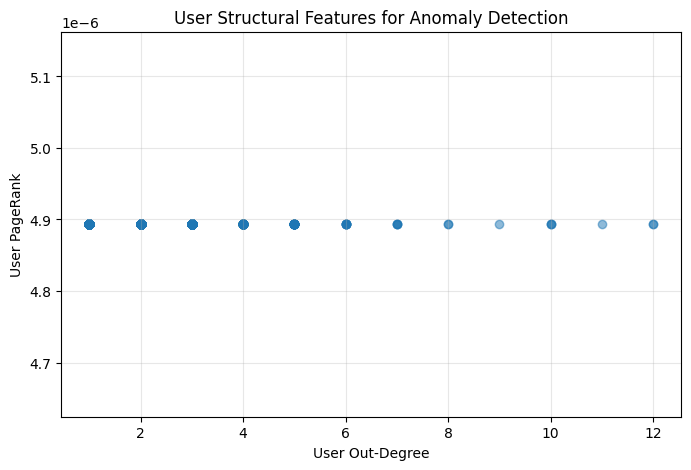

In [13]:
# ================================================================
# Cell 17: Isolation Forest anomaly detection for suspicious users
# ================================================================

user_features_pdf = user_scores_pdf.copy()

if len(user_features_pdf) < 10:
    print("Too few users for meaningful anomaly detection. Displaying available features.")
    display(user_features_pdf)
else:
    X = user_features_pdf[["out_degree", "hub", "pagerank"]].fillna(0.0)

    iso = IsolationForest(
        n_estimators=200,
        contamination=0.02,
        random_state=42
    )

    user_features_pdf["anomaly_label"] = iso.fit_predict(X)
    user_features_pdf["anomaly_score"] = iso.decision_function(X)

    suspicious_users = (
        user_features_pdf[user_features_pdf["anomaly_label"] == -1]
        .sort_values("anomaly_score")
    )

    print("Top suspicious / anomalous users by structural behavior:")
    display(suspicious_users.head(20))

    plt.figure(figsize=(8, 5))
    plt.scatter(
        user_features_pdf["out_degree"],
        user_features_pdf["pagerank"],
        alpha=0.5
    )
    plt.xlabel("User Out-Degree")
    plt.ylabel("User PageRank")
    plt.title("User Structural Features for Anomaly Detection")
    plt.grid(True, alpha=0.3)
    plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23470
           1       1.00      0.87      0.93       469

    accuracy                           1.00     23939
   macro avg       1.00      0.93      0.96     23939
weighted avg       1.00      1.00      1.00     23939



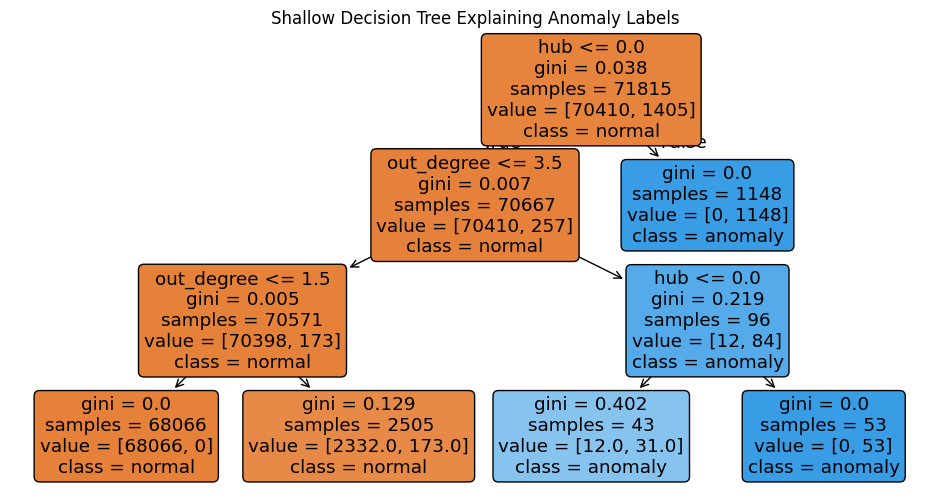

Saved: /content/drive/MyDrive/TAMU/CSCE676/final_project_outputs/figures/decision_tree_interpretability.png


In [14]:
# ================================================================
# Cell 18: Interpretability with a shallow decision tree
# ================================================================

if "anomaly_label" not in user_features_pdf.columns or len(user_features_pdf) < 20:
    print("Not enough anomaly labels for decision tree. Run Cell 17 with enough graph users.")
else:
    tree_df = user_features_pdf[["out_degree", "hub", "pagerank", "anomaly_label"]].copy()
    tree_df["is_anomaly"] = (tree_df["anomaly_label"] == -1).astype(int)

    X = tree_df[["out_degree", "hub", "pagerank"]]
    y = tree_df["is_anomaly"]

    if y.nunique() < 2:
        print("Only one class exists. Decision tree cannot be trained meaningfully.")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.25,
            random_state=42,
            stratify=y
        )

        clf = SkDecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=5,
            random_state=42
        )
        clf.fit(X_train, y_train)

        pred = clf.predict(X_test)
        print(classification_report(y_test, pred, zero_division=0))

        plt.figure(figsize=(12, 6))
        plot_tree(
            clf,
            feature_names=["out_degree", "hub", "pagerank"],
            class_names=["normal", "anomaly"],
            filled=True,
            rounded=True
        )
        plt.title("Shallow Decision Tree Explaining Anomaly Labels")
        plt.show()

        plt.figure(figsize=(12, 6))
        plot_tree(
            clf,
            feature_names=["out_degree", "hub", "pagerank"],
            class_names=["normal", "anomaly"],
            filled=True,
            rounded=True
        )
        plt.title("Shallow Decision Tree Explaining Anomaly Labels")
        plt.savefig(FIG_DIR / "decision_tree_interpretability.png", dpi=200, bbox_inches="tight")
        plt.close()

        print("Saved:", FIG_DIR / "decision_tree_interpretability.png")

## Anomaly Detection and Interpretability Interpretation

The anomaly detection layer should be interpreted as structural outlier detection, not confirmed fraud detection. Isolation Forest flags users whose graph features differ from the majority, using features such as out-degree, hub score, and PageRank.

The shallow decision tree is trained on the Isolation Forest pseudo-labels, so its purpose is interpretability rather than ground-truth prediction. In other words, the tree explains what kinds of graph features caused users to be flagged as unusual. It does not prove that those users are bots or fake reviewers.

This distinction matters because real fraud detection would require verified labels, behavioral evidence, or manual review. Here, anomaly detection is best treated as a triage tool for identifying accounts worth further investigation.

# Final Summary

## Results Summary

This project analyzed the Amazon Electronics ratings dataset with **7,824,482 user-product interactions**. After converting ratings into binary positive interactions using `rating >= 4`, the dataset contained **5,833,322 positive interactions**, meaning about **74.6%** of all ratings were positive. This confirms the rating inflation problem: most users give high ratings, so raw rating values are less informative than a positive-interaction view.

The basket-size analysis showed a strong long-tail pattern. There were about **3.26M users with positive interactions**, but the median positive basket size was only **1 product**, and the mean was only about **1.79 products**. This confirms the extreme sparsity problem: most users do not provide enough co-review history for rich basket mining, while a small number of highly active users create most of the usable co-occurrence signal.

MinHash LSH was highly effective for reducing the similarity-search space. On a sample of **50,000 users**, brute-force comparison would require about **1.25B user pairs**, while LSH reduced this to about **351,804 candidate pairs**, a search-space reduction of roughly **99.97%**. This supports the use of approximate similarity search as a practical scaling layer for sparse interaction data.

FP-Growth showed that support threshold selection strongly controls the number of discovered patterns. With `minSupport = 0.001`, the model found **213 frequent itemsets** and **2 association rules**. Increasing support to `0.002` reduced the result to **47 itemsets** and no rules; at `0.005`, only **9 itemsets** remained; and at `0.01`, no frequent itemsets were found. This means meaningful association rules are fragile in this dataset unless the threshold is kept low, because most co-occurrence patterns are sparse.

PrefixSpan found **212 frequent sequential patterns** on a 50,000-user sample. The strongest patterns were dominated by popular individual products such as `B007WTAJTO`, `B0074BW614`, `B003ES5ZUU`, and `B0019EHU8G`. This suggests that temporal mining adds useful structure, but the strongest sequence-level signal is still heavily influenced by product popularity and short user histories.

The bipartite graph analysis on a sampled graph with about **142,525 nodes** and **100,000 edges** identified structurally central products using PageRank. The top PageRank products overlapped with products found by FP-Growth and PrefixSpan, suggesting that the same head products dominate across multiple mining views: frequency, sequence position, and graph centrality.

For the embedding extension, the notebook attempts to train **64-dimensional node2vec embeddings**. If Colab runtime limitations cause node2vec multiprocessing issues, the notebook falls back to spectral graph embeddings. In either case, the goal is to produce a dense structural representation of users and products for downstream analysis.

The anomaly detection layer used graph-derived features such as out-degree, hub score, and PageRank to flag structurally unusual users. A shallow decision tree then explained these anomaly labels. This is structural outlier detection, not confirmed fraud detection, because the labels come from Isolation Forest rather than verified bot or fake-review ground truth.

## Big Takeaway

The main takeaway is that the Amazon Electronics dataset is not just large. It is **large, sparse, inflated, and popularity-skewed**.

Frequent itemset mining, sequential pattern mining, and graph analysis all point to the same reality: a small set of highly popular products dominates the observable structure. FP-Growth can recover co-review patterns, PrefixSpan can add temporal context, and PageRank can identify structurally central products, but all three methods must be interpreted carefully because popularity bias is extremely strong.

The most successful part of the project is the scalable architecture:

- Spark handled the full 7.8M-row interaction dataset.
- Bloom Filter was implemented as a proposed probabilistic defense layer for duplicate filtering before heavier computation.
- MinHash LSH reduced pairwise comparison cost by about 99.97%.
- FP-Growth and PrefixSpan extracted unordered and ordered product patterns.
- Bipartite graph analysis connected product popularity with structural authority.
- Graph embeddings and Isolation Forest extended the project toward representation learning and anomaly detection.
- A shallow decision tree provided an interpretable explanation layer for detected anomalies.

Overall, the project shows that large-scale recommendation-style mining is less about running one algorithm and more about building a layered pipeline: clean the data, reduce the search space, mine patterns, compare multiple views, and interpret the results with awareness of sparsity and popularity bias.

In [15]:
# ================================================================
# Cell 20: Export requirements.txt
# ================================================================
# Colab final-deliverable instruction:
# export the full environment, then download requirements.txt.

REQ_PATH = OUTPUT_DIR / "requirements.txt"

subprocess.run(f"{sys.executable} -m pip freeze > {REQ_PATH}", shell=True, check=True)

print("Exported:", REQ_PATH)

# Also copy a root-level requirements.txt in the current runtime for easy download.
runtime_req = Path("requirements.txt")
runtime_req.write_text(REQ_PATH.read_text())

print("Copied to:", runtime_req.resolve())

if IN_COLAB:
    from google.colab import files
    files.download("requirements.txt")
else:
    print(runtime_req.read_text()[:2000])

Exported: /content/drive/MyDrive/TAMU/CSCE676/final_project_outputs/requirements.txt
Copied to: /content/requirements.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Resources Declaration

## Collaborators

- NA

## Web Sources
- NA

## AI Tools

AI tools were used for:
ChatGPT 5.5 Thinking
- Notebook structure planning
- Code drafting and refactoring
- Explanation polishing
- Debugging support
